### Standard scaler realization

Bringing theory to practice.

In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import seaborn as sns

In [3]:
np.random.seed(2042)
DATA_SHAPE = (15, 10)

data = np.random.randint(-100, +350, size=DATA_SHAPE)
data

array([[ -6, 267, 171, -17, -80, -52, 327,  97, 267, 156],
       [-43, -52, 164,  49,  31, -80, 283,  46, 231,  -5],
       [307,  60, 346, -74,  29, 253, 339, -54, 331, 272],
       [-93, 314, 167,  90, 155, 130, 164, 275, 348, -13],
       [ 47, -65, 276, -46,  32, 121,   4, 341,  -2, 246],
       [ 27,  -3, 100, 339, -53, 194, -79,  76, -54,  10],
       [235,  60, 195, 111, -87, 308, 312,  70, -97, 228],
       [121, -63, -19, 316, -77,  97, 319, 341, 340, 170],
       [187, 243, 277,   2, 212, 338, 321, 284, 313, 174],
       [256,  38,  47, -27, -12, 114, 250, 284, 143,  84],
       [308, -40,   5, 283, -92,  37, 116, -73, 157, 194],
       [268,  67, 158, 146, 320, 295, 118, 258, -96, 208],
       [225,  19, -60,  15, 186, 321,  14, -58,  74, 292],
       [  0, -59,  33, -73, -91, -56, 257, -17, -61, 291],
       [205, 253, 269, 194, 248, 349, 229, 228, 300, 208]])

#### Meaning of standartization

Standartization here is making mean value of all distribution == 0 and its standart deviation == 1, quite simple:

(FEATx - FEATmean)/SD

In [5]:
# TRAINING THE SCALER

# calculating mean values
mean = data.mean()
print('Mean value of our dataset =', mean)

# calculating SD
sd = data.std()
print('Standart deviation of our dataset =', sd)

Mean value of our dataset = 129.27333333333334
Standart deviation of our dataset = 142.06570764575415


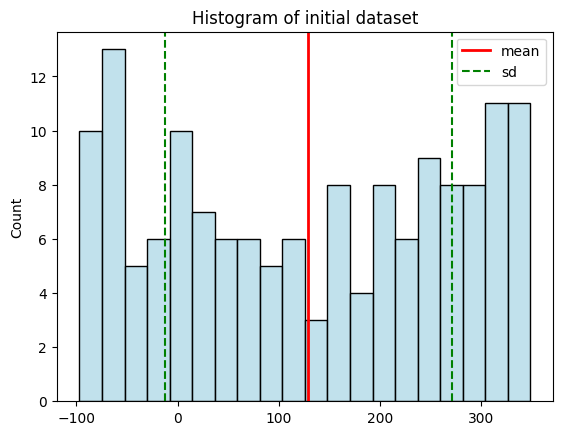

In [6]:
# lets draw it!

ax = sns.histplot(data.ravel(), bins=20, color='lightblue');
ax.axvline(mean, color='red', label='mean', linewidth=2)
ax.axvline(mean-sd, color='green', label='sd', linestyle='--')
ax.axvline(mean+sd, color='green', linestyle='--')
ax.set_title('Histogram of initial dataset')
ax.legend();

In [7]:
data_scaled = np.zeros_like(data, dtype='float')

for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        data_scaled[i][j] = (data[i][j] - mean) / sd

new_mean = data_scaled.mean()
new_sd = data_scaled.std()
print('Scaled data:')
print(data_scaled)
print('\nMean values of scaled data =', new_mean)
print('Standart deviation of scaled data =', new_sd)

Scaled data:
[[-0.9521885   0.96945751  0.29371386 -1.02961746 -1.47307423 -1.27598233
   1.39179729 -0.22717188  0.96945751  0.18812891]
 [-1.21263137 -1.27598233  0.24444088 -0.5650437  -0.69174564 -1.47307423
   1.08208145 -0.58616069  0.71605364 -0.94514951]
 [ 1.25101736 -0.48761474  1.52553822 -1.43084025 -0.70582363  0.87091156
   1.47626524 -1.29006033  1.41995327  1.00465249]
 [-1.56458119  1.30029034  0.26555787 -0.27644485  0.18108991  0.005115
   0.24444088  1.02576948  1.53961621 -1.00146148]
 [-0.57912169 -1.36748929  1.03280847 -1.23374836 -0.68470664 -0.05823596
  -0.88179854  1.49034324 -0.92403252  0.82163858]
 [-0.71990162 -0.93107151 -0.20605489  1.47626524 -1.28302133  0.45561077
  -1.46603524 -0.3749908  -1.29006033 -0.83956456]
 [ 0.74420962 -0.48761474  0.46264977 -0.12862593 -1.52234721  1.25805636
   1.28621234 -0.41722478 -1.59273717  0.69493665]
 [-0.05823596 -1.35341129 -1.04369545  1.31436833 -1.45195724 -0.22717188
   1.33548532  1.49034324  1.48330424  0

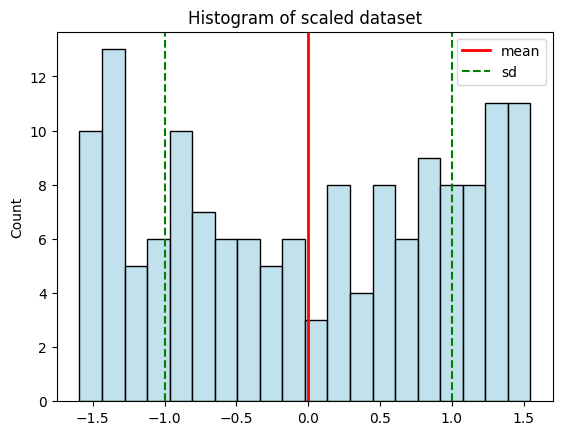

In [8]:
# lets draw it too!

ax1 = sns.histplot(data_scaled.ravel(), bins=20, color='lightblue');
ax1.axvline(new_mean, color='red', label='mean', linewidth=2)
ax1.axvline(new_mean-new_sd, color='green', label='sd', linestyle='--')
ax1.axvline(new_mean+new_sd, color='green', linestyle='--')
ax1.set_title('Histogram of scaled dataset')
ax1.legend();

**Looks like it works! Mean value is 0, standard deviation is (-1, +1)-ish**

#### Lets check, how it corresponds with Sklearn version!

In [11]:
sk_scaler = StandardScaler()

sk_scaled_data = sk_scaler.fit_transform(data)

# calculating mean values
sk_mean = sk_scaled_data.mean()
print('Mean value of our dataset =', sk_mean)

# calculating SD
sk_sd = sk_scaled_data.std()
print('Standart deviation of our dataset =', sk_sd)

Mean value of our dataset = -2.3684757858670008e-17
Standart deviation of our dataset = 1.0


Is our results different from SKlearn version?

In [13]:
print('First 10 numbers that we scaled "manually":', data_scaled[0][:9])
print('First 10 numbers that we scaled by Sklearn:', sk_scaled_data[0][:9])

First 10 numbers that we scaled "manually": [-0.9521885   0.96945751  0.29371386 -1.02961746 -1.47307423 -1.27598233
  1.39179729 -0.22717188  0.96945751]
First 10 numbers that we scaled by Sklearn: [-1.0828841   1.53023802  0.24736921 -0.76713045 -0.94543126 -1.44631281
  0.98510357 -0.28957543  0.72689175]


#### THAT WAS ALL WRONG lol

Hmm it's actually different scaling :D

...

_some times later..._

Turned out we've been calculating mean and sd for the whole features together, but it doesn't work that way:<br>

_Centering and scaling happen independently on each feature by computing the relevant statistics on the samples in the training set_ <br>
https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html

##### Well it's not a big challenge for а newbie data-scientist is it not ))

### Making scaling - properly this time :)

In [18]:
# lets calculate mean and std for each feature and store it

feat_scaling_params = []

for i in range(data.shape[1]):

    # IMPORTANT ONE: we're assuming that features are columns, not rows
    # - so we calculate mean & std of __column__
    feat_mean = data[:data.shape[0], i].mean()
    feat_sd = data[:data.shape[0], i].std()
    feat_scaling_params.append((feat_mean, feat_sd))

# dict is not neсessary here but looks more "readable"
means = [m for m, s in feat_scaling_params]
stds  = [s for m, s in feat_scaling_params]
feat_scaling_dict = {'mean': means, 'std': stds}

In [19]:
# here we're doing the scaling itself

data_proper_scaled = np.zeros_like(data, dtype='float')

for i in range(data.shape[1]):
    for j in range(data.shape[0]):

        # we're assuming that features are columns, not rows - so we reverse indexes
        data_proper_scaled[j][i] = (data[j][i] - feat_scaling_dict['mean'][i]) / feat_scaling_dict['std'][i]

#### Lets check once again: is our results different from SKlearn version?

In [21]:
print('First 10 numbers that we scaled "manually":', data_proper_scaled[0][:9])
print('First 10 numbers that we scaled by Sklearn:', sk_scaled_data[0][:9])

First 10 numbers that we scaled "manually": [-1.0828841   1.53023802  0.24736921 -0.76713045 -0.94543126 -1.44631281
  0.98510357 -0.28957543  0.72689175]
First 10 numbers that we scaled by Sklearn: [-1.0828841   1.53023802  0.24736921 -0.76713045 -0.94543126 -1.44631281
  0.98510357 -0.28957543  0.72689175]


#### Now thats proper math :)

We have successfully written the scaler that acts just like "grownup" scaler from Sklearn!